# LME-SHFE Physical Arbitrage & Cost Stack Model
**Quantitative Analysis of the Gross-to-Net Basis across Base Metals**

This notebook is dedicated to the comprehensive modeling of the physical arbitrage window between the London Metal Exchange (LME) and the Shanghai Futures Exchange (SHFE). 

Moving beyond a simple theoretical price differential (Gross Basis), this model dynamically reconstructs the entire **Physical Cost Stack** required to move and import refined metals into China. It calculates, step-by-step, the historical impact of:
- **Logistics & Shipping:** Ocean Freight Base, Bunker Adjustment Factor (BAF, via VLSFO), and Currency Adjustment Factor (CAF).
- **Financing:** Cost of Carry (dynamically linked to SOFR rates) and VAT financing constraints.
- **Frictions:** Insurance, physical import duties, and structural execution risks.

The ultimate goal of this pipeline is to erode the Gross Basis to isolate the true **Net Basis**. Finally, the model runs a realistic, scenario-based backtest (Aggressive, Base, and Conservative slippage) to evaluate the actual profitability, hit rate, and logistical risk of the arbitrage strategy across the 2016-2025 timeline.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

METALS_FILE     = 'METALS_Final_v2.xlsx'
COST_STACK_FILE = 'COST_STACK.xlsx'
FX_FILE         = 'FX.xlsx'

metals = ['Copper', 'Aluminium', 'Nickel', 'Lead', 'Tin', 'Zinc']

# --- trade parameters (defined FIRST so VAT/Transit_days are
#     available to the gross-basis formula below) ---
Transit_days       = 35
Route_distance     = 11800
Vessel_consumption = 45
VAT                = 0.13
VAT_recovery_days  = 45
Insurance_rate     = 0.001
Import_duty        = {m: 0.00 for m in metals}
Lot_size           = {'Copper':25,'Aluminium':25,'Nickel':6,'Lead':25,'Tin':5,'Zinc':25}
Metal_BDI_index    = {'Copper':'Capesize','Aluminium':'Capesize','Nickel':'Handymax',
                      'Lead':'Supramax','Tin':'Handymax','Zinc':'Supramax'}


def _read_dated_sheet(path, sheet, header=0):
    df = pd.read_excel(path, sheet_name=sheet, header=header, index_col=0)
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[~df.index.isna()]
    df = df[~df.index.duplicated(keep='first')]
    df = df.apply(pd.to_numeric, errors='coerce')
    return df

# --- metals prices: header at row 0 ---
LME_cash = _read_dated_sheet(METALS_FILE, 'LME CLEAN DATA')
LME_3m   = _read_dated_sheet(METALS_FILE, 'LME 3M')
SHFE     = _read_dated_sheet(METALS_FILE, 'SHFE CLEAN DATA')

LME_cash = LME_cash.rename(columns={
    'LME-Copper Cash Comp U$/MT':'Copper',
    'LME-Aluminium Cash Comp U$/MT':'Aluminium',
    'LME-Nickel  Comp U$/MT':'Nickel',
    'LME-Lead Cash Comp U$/MT':'Lead',
    'LME-Tin Cash Comp U$/MT':'Tin',
    'LME-Zinc Cash U$/MT':'Zinc'
})
for need, df_name, df in [
        (metals,                       'LME_cash', LME_cash),
        ([f'{m}_3m' for m in metals],  'LME_3m',   LME_3m),
        (metals,                       'SHFE',     SHFE)]:
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(
            f"After loading {df_name}, missing columns {missing}. "
            f"Available: {list(df.columns)}"
        )

# --- FX (header row 0) ---
FX = _read_dated_sheet(METALS_FILE, 'FX')

# --- align indexes; build gross basis (net of VAT: the SHFE quote
#     is gross of 13% Chinese import VAT, so it is stripped before
#     converting CNY → USD; the residual vs LME is the arbitrageable spread) ---
common_idx   = LME_cash.index.intersection(SHFE.index).intersection(FX.index)
LME_aligned  = LME_cash.loc[common_idx]
SHFE_aligned = SHFE.loc[common_idx]
FX_aligned   = FX.loc[common_idx]

SHFE_usd    = pd.DataFrame(index=common_idx)
Gross_basis = pd.DataFrame(index=common_idx)
for metal in metals:
    SHFE_usd[metal]    = SHFE_aligned[metal] / FX_aligned['USDCNY'] / (1 + VAT)
    Gross_basis[metal] = SHFE_usd[metal] - LME_aligned[metal]

# --- cost-stack inputs: every sheet has header at row 0 ---
Freight   = _read_dated_sheet(COST_STACK_FILE, 'Freight')
Oil       = _read_dated_sheet(COST_STACK_FILE, 'Oil')
Int_rates = _read_dated_sheet(COST_STACK_FILE, 'Interest Rates')
for df in [Freight, Oil, Int_rates]:
    df.ffill(inplace=True)

Freight   = Freight.rename(columns={'.BADI':'Baltic Dry Index','.BACI':'Capesize',
                                     '.BHSI':'Handymax','.BASI':'Supramax'})
Oil       = Oil.rename(columns={'LCOc1':'Brent_F1','LCOc3':'Brent_F3',
                                 'CLc1':'WTI','BKVLSFO-RDM-CLY':'VLSFO'})
Int_rates = Int_rates.rename(columns={'USDSOFR=':'SOFR','USDSOFR3M=R':'SOFR3M',
                                       'SHIBOR3M=':'SHIBOR3M','EUR3MD=':'EURIBOR3M'})

# --- FIX: SOFR3M is zero throughout 2016-2017 because the SOFR term
#     rate did not exist before April 2018 (the NY Fed launched SOFR
#     on 2018-04-03). The data provider back-fills the pre-launch
#     window with 0, which would zero out CoC and VAT financing for
#     two full years (~$15-50/t understatement for high-value metals).
#     Fix: where SOFR3M == 0, substitute the overnight SOFR rate
#     (term-premium ≈ 0-15 bps in this regime, acceptable proxy).
zero_sofr3m = Int_rates['SOFR3M'] == 0
if zero_sofr3m.any():
    Int_rates.loc[zero_sofr3m, 'SOFR3M'] = Int_rates.loc[zero_sofr3m, 'SOFR']
    n_filled = int(zero_sofr3m.sum())
    print(f'  SOFR3M proxy fill: {n_filled} rows replaced with SOFR overnight '
          f'(SOFR term rate did not exist pre-2018-04).')

USDCNY    = FX[['USDCNY']]

# --- freight base ---
def freight_base_fn(metal, base_freight_usdpt=120.0):
    col     = Metal_BDI_index[metal]
    sub_idx = Freight[col].dropna()
    BETA    = 0.04
    fb      = base_freight_usdpt + BETA * (sub_idx - sub_idx.mean())
    return fb.clip(lower=40).rename(f'freight_base_{metal}')

def Baf(Oil, transit_days, consumption, cargo_tonnes: float = 25000) -> pd.Series:
    vlsfo = Oil['VLSFO'].dropna()
    baf = (consumption * transit_days * vlsfo) / cargo_tonnes
    baf = baf.clip(lower=10)
    print(f"  BAF: mean = ${baf.mean():.1f}/t | "
          f"min = ${baf.min():.1f}/t | max = ${baf.max():.1f}/t")
    return baf.rename('BAF')

df_BAF = pd.DataFrame(Baf(Oil, Transit_days, Vessel_consumption, 25000))

# --- freight_base from sheet (header at row 0) ---
freight_base_df = pd.read_excel(COST_STACK_FILE, sheet_name='Freight Base',
                                 header=0, index_col=0)
freight_base_df.index = pd.to_datetime(freight_base_df.index, errors='coerce')
freight_base_df = freight_base_df[~freight_base_df.index.isna()]

# --- CAF (sensitività 0.35 come da modifica utente) ---
vlsfo     = Oil['VLSFO'].dropna()
fx_series = FX['USDCNY']
caf_dict  = {}
for metal in metals:
    fb      = freight_base_df[f'freight_base_{metal}']
    common  = fb.index.intersection(fx_series.index)
    caf_pct = (0.35 * (fx_series.loc[common] - 7.0) / 7.0).clip(-0.15, 0.15)
    caf_dict[f'Caf_{metal.lower()}'] = (fb.loc[common] * caf_pct)
df_Caf_tot = pd.DataFrame(caf_dict)

print(f'✅')
print(f'   LME_aligned : {LME_aligned.shape}  cols={list(LME_aligned.columns)}')
print(f'   SHFE_aligned: {SHFE_aligned.shape}  cols={list(SHFE_aligned.columns)}')
print(f'   FX_aligned  : {FX_aligned.shape}    cols={list(FX_aligned.columns)[:4]} ...')
print(f'   Freight     : {Freight.shape}  cols={list(Freight.columns)}')
print(f'   Oil         : {Oil.shape}      cols={list(Oil.columns)}')
print(f'   Int_rates   : {Int_rates.shape}  cols={list(Int_rates.columns)}')


  SOFR3M proxy fill: 624 rows replaced with SOFR overnight (SOFR term rate did not exist pre-2018-04).
  BAF: mean = $32.9/t | min = $10.0/t | max = $64.8/t
✅
   LME_aligned : (2430, 6)  cols=['Copper', 'Aluminium', 'Nickel', 'Lead', 'Tin', 'Zinc']
   SHFE_aligned: (2430, 6)  cols=['Copper', 'Aluminium', 'Nickel', 'Lead', 'Tin', 'Zinc']
   FX_aligned  : (2430, 5)    cols=['USDCNY', 'USDCNY 1M', 'USDCNY 3M', 'USDEUR'] ...
   Freight     : (2496, 4)  cols=['Baltic Dry Index', 'Capesize', 'Handymax', 'Supramax']
   Oil         : (2582, 4)      cols=['Brent_F1', 'Brent_F3', 'WTI', 'VLSFO']
   Int_rates   : (2496, 5)  cols=['SOFR', 'SOFR3M', 'delta ', 'SHIBOR3M', 'EURIBOR3M']


---
## COST OF CARRY

In [21]:
# ─────────────────────────────────────────────────────────────
# COST OF CARRY
# Formula: CoC ($/t) = P_lme × SOFR × (Transit_days / 365)
# Logic: the metal is purchased (cash out) on day 0 but the sale
# proceeds arrive only after Transit_days. The desk finances this
# working capital at SOFR3M — the most appropriate tenor.
# ─────────────────────────────────────────────────────────────

def cost_of_carry(metal: str,
                  lme_aligned: pd.DataFrame,
                  int_rates: pd.DataFrame,
                  transit_days: int = Transit_days,
                  rate_col: str = 'SOFR3M') -> pd.Series:
    """
    Returns daily cost of carry in $/t for a given metal.
    SOFR3M is used as the financing rate (annualised, in %).
    """
    price  = lme_aligned[metal].dropna()
    rate   = int_rates[rate_col].dropna()

    common = price.index.intersection(rate.index)
    coc    = price.loc[common] * rate.loc[common] * (transit_days / 365)

    return coc.rename(f'CoC_{metal}')


# --- compute for all 6 metals ---
coc_dict = {}
for metal in metals:
    s = cost_of_carry(metal, LME_aligned, Int_rates)
    coc_dict[f'CoC_{metal}'] = s
    print(f'  {metal:<12} CoC mean = ${s.mean():.1f}/t  '
          f'(range ${s.min():.1f} – ${s.max():.1f}/t)')

df_CoC = pd.DataFrame(coc_dict)
print(f'\n✅ Cost of carry computed: {df_CoC.shape[0]} obs x {df_CoC.shape[1]} metals')

  Copper       CoC mean = $17.0/t  (range $0.1 – $55.4/t)
  Aluminium    CoC mean = $4.7/t  (range $0.0 – $14.0/t)
  Nickel       CoC mean = $34.7/t  (range $0.2 – $117.2/t)
  Lead         CoC mean = $4.3/t  (range $0.0 – $11.8/t)
  Tin          CoC mean = $54.8/t  (range $0.3 – $183.0/t)
  Zinc         CoC mean = $5.7/t  (range $0.0 – $16.1/t)

✅ Cost of carry computed: 2329 obs x 6 metals


---
## VAT FINANCING COST

In [22]:
# ─────────────────────────────────────────────────────────────
# VAT FINANCING COST
# The 13% Chinese import VAT is paid at customs on arrival.
# It is recoverable as a tax credit but only after VAT_recovery_days.
# During that period the cash is tied up — the financing cost is:
#
# VAT_cost ($/t) = P_lme × VAT_rate × SOFR × (VAT_recovery_days / 365)
# ─────────────────────────────────────────────────────────────

def vat_financing(metal: str,
                  lme_aligned: pd.DataFrame,
                  int_rates: pd.DataFrame,
                  vat_rate: float = VAT,
                  recovery_days: int = VAT_recovery_days,
                  rate_col: str = 'SOFR3M') -> pd.Series:
    """
    Returns daily VAT financing cost in $/t.
    """
    price  = lme_aligned[metal].dropna()
    rate   = int_rates[rate_col].dropna()

    common   = price.index.intersection(rate.index)
    vat_cost = (price.loc[common]
                * vat_rate
                * rate.loc[common]
                * (recovery_days / 365))

    return vat_cost.rename(f'VAT_{metal}')


vat_dict = {}
for metal in metals:
    s = vat_financing(metal, LME_aligned, Int_rates)
    vat_dict[f'VAT_{metal}'] = s
    print(f'  {metal:<12} VAT financing mean = ${s.mean():.1f}/t')

df_VAT = pd.DataFrame(vat_dict)
print(f'\n✅ VAT financing computed: {df_VAT.shape[0]} obs x {df_VAT.shape[1]} metals')

  Copper       VAT financing mean = $2.8/t
  Aluminium    VAT financing mean = $0.8/t
  Nickel       VAT financing mean = $5.8/t
  Lead         VAT financing mean = $0.7/t
  Tin          VAT financing mean = $9.2/t
  Zinc         VAT financing mean = $0.9/t

✅ VAT financing computed: 2329 obs x 6 metals


---
## INSURANCE (CIF ICC-C)

In [23]:
# ─────────────────────────────────────────────────────────────
# INSURANCE — CIF ICC-C minimum coverage
# Formula: insurance ($/t) = Insurance_rate × P_lme
# ICC-C is the minimum CIF clause (~0.1% of cargo value).
# This is a minor component (~$2-4/t) but included for completeness.
# ─────────────────────────────────────────────────────────────

ins_dict = {}
for metal in metals:
    s = (LME_aligned[metal].dropna() * Insurance_rate).rename(f'Ins_{metal}')
    ins_dict[f'Ins_{metal}'] = s
    print(f'  {metal:<12} Insurance mean = ${s.mean():.1f}/t')

df_Insurance = pd.DataFrame(ins_dict)
print(f'\n✅ Insurance computed: {df_Insurance.shape[0]} obs x {df_Insurance.shape[1]} metals')

  Copper       Insurance mean = $7.6/t
  Aluminium    Insurance mean = $2.2/t
  Nickel       Insurance mean = $15.9/t
  Lead         Insurance mean = $2.1/t
  Tin          Insurance mean = $24.8/t
  Zinc         Insurance mean = $2.8/t

✅ Insurance computed: 2430 obs x 6 metals


---
## TOTAL COST STACK

In [24]:
# ─────────────────────────────────────────────────────────────
# TOTAL COST STACK
# Assembles all components on a common daily index.
#
# cost_stack = freight_base + BAF + CAF + CoC + VAT + Insurance
#              (+ import_duty = 0 for all metals currently)
# ─────────────────────────────────────────────────────────────

# We first find the global common index across ALL data sources
all_series_idx = [
    LME_aligned.index,
    freight_base_df.index,
    df_BAF.index,
    df_Caf_tot.index,
    df_CoC.index,
    df_VAT.index,
    df_Insurance.index,
]
global_idx = all_series_idx[0]
for idx in all_series_idx[1:]:
    global_idx = global_idx.intersection(idx)

print(f'Global common index: {global_idx[0].date()} → {global_idx[-1].date()} ({len(global_idx)} obs)\n')

# --- build total cost stack per metal ---
Total_cost_stack = pd.DataFrame(index=global_idx)

for metal in metals:
    m = metal.lower()

    freight = freight_base_df[f'freight_base_{metal}'].reindex(global_idx, method='ffill')
    baf     = df_BAF['BAF'].reindex(global_idx, method='ffill')
    caf     = df_Caf_tot[f'Caf_{m}'].reindex(global_idx, method='ffill')
    coc     = df_CoC[f'CoC_{metal}'].reindex(global_idx, method='ffill')
    vat     = df_VAT[f'VAT_{metal}'].reindex(global_idx, method='ffill')
    ins     = df_Insurance[f'Ins_{metal}'].reindex(global_idx, method='ffill')
    duty    = LME_aligned[metal].reindex(global_idx) * Import_duty[metal]  # = 0

    Total_cost_stack[metal] = (freight + baf + caf + coc + vat + ins + duty)

    print(f'  {metal:<12}  '
          f'freight={freight.mean():.0f}  '
          f'BAF={baf.mean():.0f}  '
          f'CAF={caf.mean():.0f}  '
          f'CoC={coc.mean():.0f}  '
          f'VAT={vat.mean():.0f}  '
          f'Ins={ins.mean():.0f}  '
          f'→ TOTAL={Total_cost_stack[metal].mean():.0f} $/t')

print(f'\n✅ Total cost stack assembled for {len(metals)} metals')

Global common index: 2016-01-04 → 2025-12-24 (2263 obs)

  Copper        freight=120  BAF=33  CAF=-1  CoC=17  VAT=3  Ins=8  → TOTAL=179 $/t
  Aluminium     freight=120  BAF=33  CAF=-1  CoC=5  VAT=1  Ins=2  → TOTAL=160 $/t
  Nickel        freight=120  BAF=33  CAF=-1  CoC=35  VAT=6  Ins=16  → TOTAL=208 $/t
  Lead          freight=120  BAF=33  CAF=-1  CoC=4  VAT=1  Ins=2  → TOTAL=159 $/t
  Tin           freight=120  BAF=33  CAF=-1  CoC=55  VAT=9  Ins=25  → TOTAL=241 $/t
  Zinc          freight=120  BAF=33  CAF=-1  CoC=6  VAT=1  Ins=3  → TOTAL=161 $/t

✅ Total cost stack assembled for 6 metals


---
## NET BASIS

In [25]:
# ─────────────────────────────────────────────────────────────
# NET BASIS
# net_basis = gross_basis − total_cost_stack
# net_basis > 0  →  arbitrage window open (profitable)
# net_basis ≤ 0  →  no arbitrage after costs
# ─────────────────────────────────────────────────────────────

Net_basis   = pd.DataFrame(index=global_idx)
Gross_basis_aligned = Gross_basis.reindex(global_idx)

for metal in metals:
    Net_basis[metal] = Gross_basis_aligned[metal] - Total_cost_stack[metal]

# ── summary table ──
summary = pd.DataFrame({
    'Gross basis mean ($/t)':    Gross_basis_aligned[metals].mean().round(1),
    'Total cost stack ($/t)':    Total_cost_stack[metals].mean().round(1),
    'Net basis mean ($/t)':      Net_basis[metals].mean().round(1),
    'Net basis std ($/t)':       Net_basis[metals].std().round(1),
    'Net basis min ($/t)':       Net_basis[metals].min().round(1),
    'Net basis max ($/t)':       Net_basis[metals].max().round(1),
    'Arb window open (%)':       (Net_basis[metals] > 0).mean().mul(100).round(1),
    'Observations':              Net_basis[metals].count(),
})

print('\n── NET BASIS SUMMARY ──')
print(summary.to_string())

print(f'\n✅ Net basis computed')


── NET BASIS SUMMARY ──
           Gross basis mean ($/t)  Total cost stack ($/t)  Net basis mean ($/t)  Net basis std ($/t)  Net basis min ($/t)  Net basis max ($/t)  Arb window open (%)  Observations
Copper                      106.8                   179.4                 -72.7                163.8              -1254.6                457.6                 35.1          2263
Aluminium                    -1.0                   159.7                -160.7                131.2               -733.1                139.5                  9.2          2263
Nickel                      183.8                   208.1                 -24.3                773.6             -14849.6               4811.5                 56.4          2263
Lead                         46.7                   159.1                -112.4                190.7               -628.9                410.4                 24.4          2263
Tin                        -407.1                   240.6                -647.7      

---
## NET BASIS VISUALIZATION

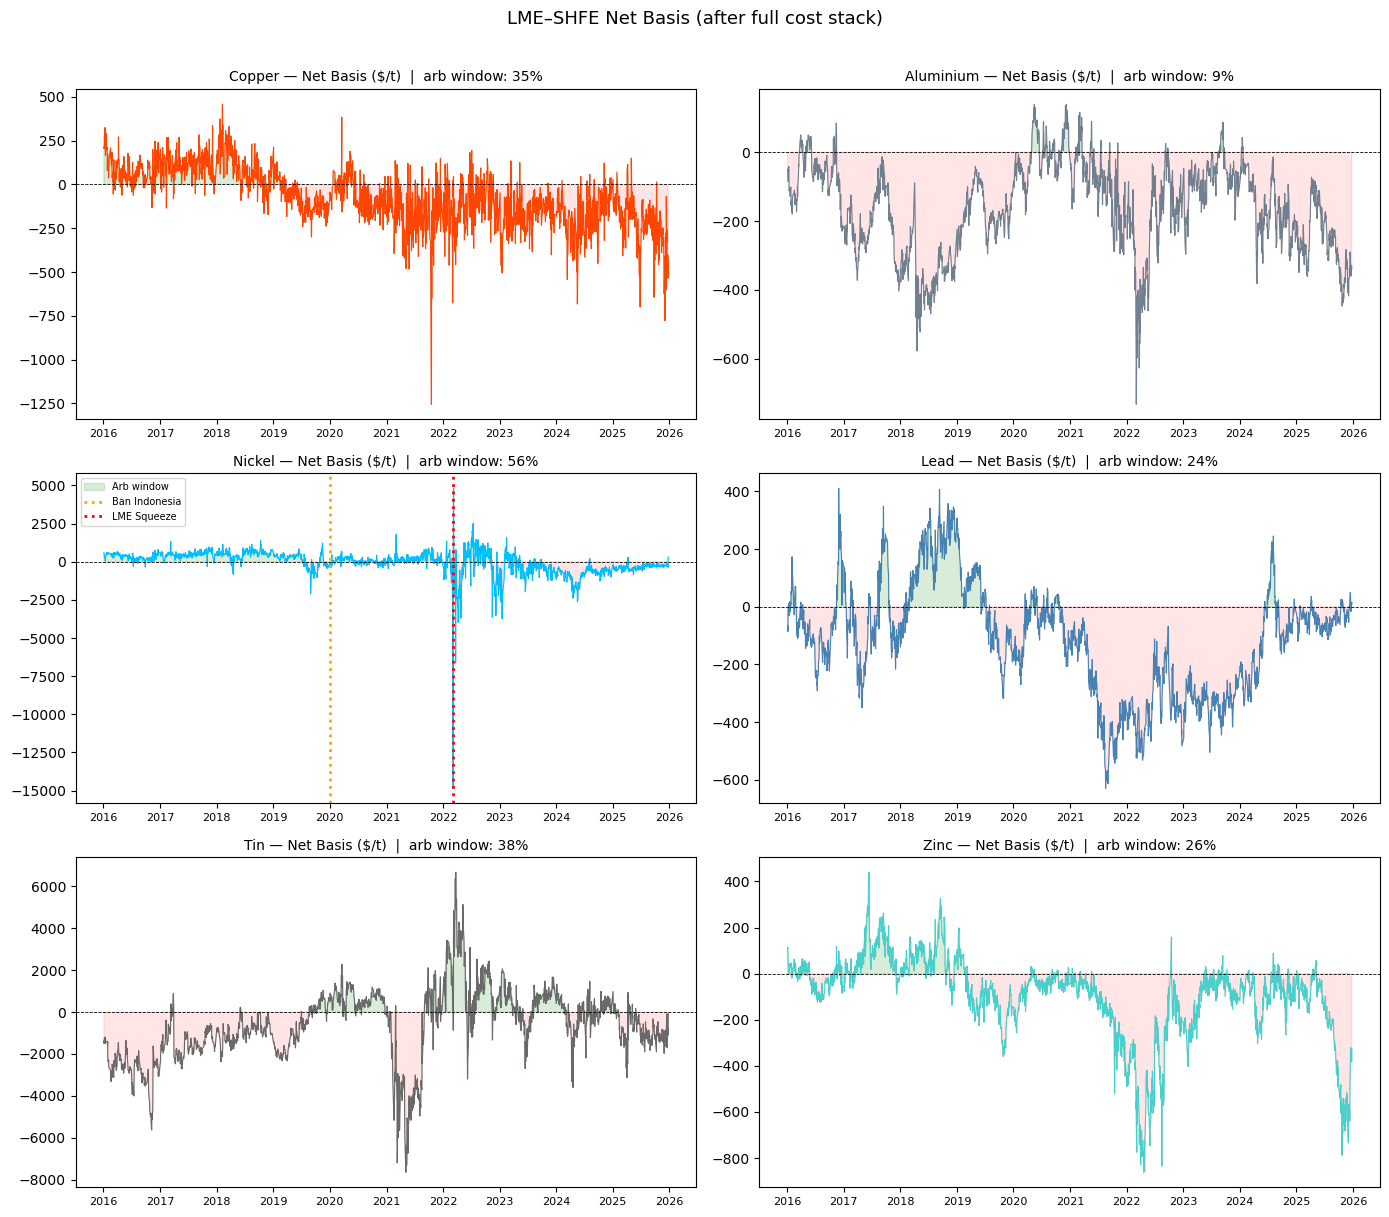

✅ Plot saved: net_basis_all_metals.png


In [26]:
# ─────────────────────────────────────────────────────────────
# NET BASIS VISUALIZATION — 6 panels
# Shows net basis over time with arb-window shading
# ─────────────────────────────────────────────────────────────

metal_colors = {
    'Copper':    'orangered',
    'Aluminium': 'slategrey',
    'Nickel':    'deepskyblue',
    'Lead':      'steelblue',
    'Tin':       'dimgrey',
    'Zinc':      'mediumturquoise',
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, metal in enumerate(metals):
    ax    = axes[i]
    color = metal_colors[metal]
    s     = Net_basis[metal].dropna()

    # main line
    ax.plot(s.index, s.values, linewidth=0.8, color=color)

    # green shading above zero = arb window open
    ax.fill_between(s.index, s.values, 0,
                    where=(s.values > 0),
                    alpha=0.15, color='green', label='Arb window')

    # red shading below zero = no arb
    ax.fill_between(s.index, s.values, 0,
                    where=(s.values <= 0),
                    alpha=0.10, color='red')

    # zero line
    ax.axhline(0, color='black', linestyle='--', linewidth=0.6)

    # nickel structural breaks
    if metal == 'Nickel':
        ax.axvline(pd.Timestamp('2020-01-01'), color='orange',
                   linestyle=':', linewidth=2, label='Ban Indonesia')
        ax.axvline(pd.Timestamp('2022-03-08'), color='red',
                   linestyle=':', linewidth=2, label='LME Squeeze')
        ax.legend(fontsize=7, loc='upper left')

    # arb % annotation in title
    arb_pct = (s > 0).mean() * 100
    ax.set_title(f'{metal} — Net Basis ($/t)  |  arb window: {arb_pct:.0f}%',
                 fontsize=10)
    ax.set_xlabel('')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('LME–SHFE Net Basis (after full cost stack)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('net_basis_all_metals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: net_basis_all_metals.png')

---
## COST STACK DECOMPOSITION — waterfall per metal

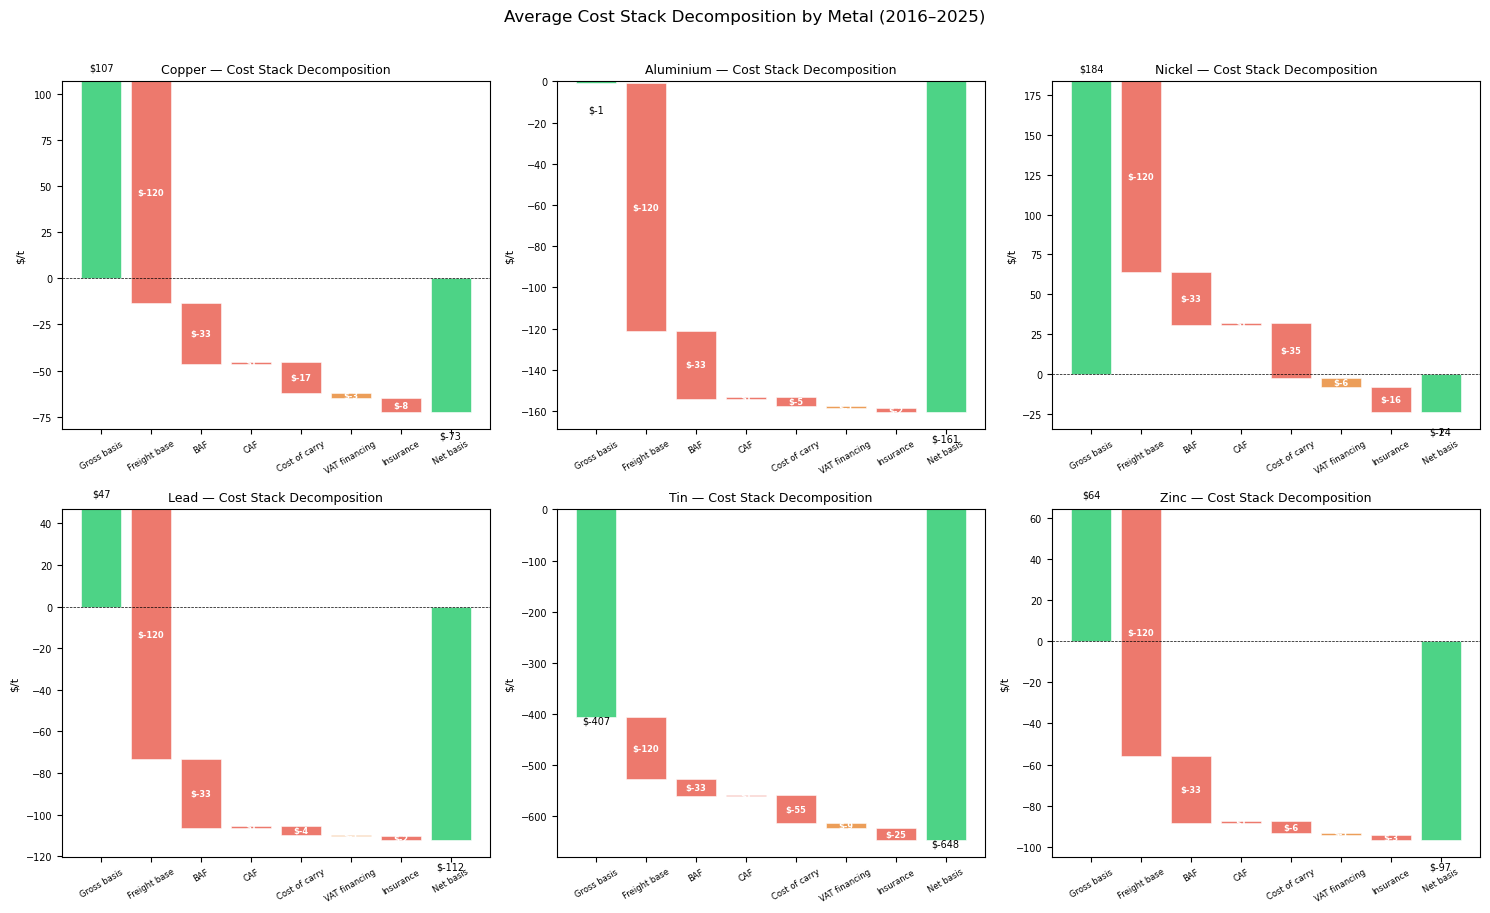

✅ Plot saved: cost_stack_waterfall.png


In [27]:
# ─────────────────────────────────────────────────────────────
# WATERFALL CHART — average cost stack decomposition
# Shows how gross basis erodes into net basis component by component
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

components = ['Gross basis', 'Freight base', 'BAF', 'CAF',
              'Cost of carry', 'VAT financing', 'Insurance', 'Net basis']
bar_colors  = ['#2ecc71', '#e74c3c', '#e74c3c', '#e74c3c',
               '#e74c3c', '#e67e22', '#e74c3c', '#2ecc71']

for i, metal in enumerate(metals):
    m   = metal.lower()
    idx = global_idx

    vals = [
        Gross_basis_aligned[metal].mean(),
        -freight_base_df[f'freight_base_{metal}'].reindex(idx, method='ffill').mean(),
        -df_BAF['BAF'].reindex(idx, method='ffill').mean(),
        -df_Caf_tot[f'Caf_{m}'].reindex(idx, method='ffill').mean(),
        -df_CoC[f'CoC_{metal}'].reindex(idx, method='ffill').mean(),
        -df_VAT[f'VAT_{metal}'].reindex(idx, method='ffill').mean(),
        -df_Insurance[f'Ins_{metal}'].reindex(idx, method='ffill').mean(),
        Net_basis[metal].mean(),
    ]

    ax = axes[i]

    # running bottom for waterfall
    running = 0
    for j, (comp, val) in enumerate(zip(components, vals)):
        if comp in ['Gross basis', 'Net basis']:
            ax.bar(comp, val, color=bar_colors[j], alpha=0.85,
                   edgecolor='white', linewidth=0.5)
            ax.text(j, val + (5 if val >= 0 else -15),
                    f'${val:.0f}', ha='center', va='bottom', fontsize=7)
            running = val
        else:
            ax.bar(comp, val, bottom=running,
                   color=bar_colors[j], alpha=0.75,
                   edgecolor='white', linewidth=0.5)
            ax.text(j, running + val/2,
                    f'${val:.0f}', ha='center', va='center',
                    fontsize=6, color='white', fontweight='bold')
            running += val

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f'{metal} — Cost Stack Decomposition', fontsize=9)
    ax.set_ylabel('$/t', fontsize=8)
    ax.tick_params(axis='x', labelsize=6, rotation=30)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Average Cost Stack Decomposition by Metal (2016–2025)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('cost_stack_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: cost_stack_waterfall.png')

---
## SENSITIVITY ANALYSIS

In [28]:
# ─────────────────────────────────────────────────────────────
# SENSITIVITY ANALYSIS
# For each metal: how much does net basis change per unit shock
# on each cost driver?
#
# Shocks:
#   VLSFO   +$10/t  → ΔBAF → Δnet_basis
#   USD/CNY +1%     → ΔCAF + Δgross_basis → Δnet_basis
#   SOFR    +25bps  → Δ(CoC + VAT)        → Δnet_basis
#   BDI     +100pts → Δfreight_base        → Δnet_basis
#   Transit +1 day  → Δ(CoC + VAT)         → Δnet_basis
# ─────────────────────────────────────────────────────────────

sensitivity_rows = []

for metal in metals:
    avg_lme = LME_aligned[metal].reindex(global_idx).mean()
    avg_fb  = freight_base_df[f'freight_base_{metal}'].reindex(global_idx, method='ffill').mean()

    # VLSFO +$10/t → BAF increases by:
    d_baf = -(Vessel_consumption * Transit_days * 10) / 25000

    # USD/CNY +1% → (a) CAF increases, (b) SHFE_usd decreases (hurts gross basis)
    # Effect on gross basis: SHFE_usd = SHFE_cny / USDCNY
    # If USDCNY +1% → SHFE_usd −1% → gross_basis drops by ~1% × avg SHFE_usd
    avg_shfe_usd = SHFE_usd[metal].reindex(global_idx).mean()
    d_gross_fx   = -0.01 * avg_shfe_usd  # gross basis effect
    d_caf        = -(avg_fb * 0.05 * 0.01 / 1.0)  # CAF effect (small)
    d_fx_total   = d_gross_fx + d_caf

    # SOFR +25bps → CoC + VAT increase
    d_coc_sofr  = -(avg_lme * 0.0025 * Transit_days / 365)
    d_vat_sofr  = -(avg_lme * VAT * 0.0025 * VAT_recovery_days / 365)
    d_sofr_total = d_coc_sofr + d_vat_sofr

    # BDI +100 pts → freight_base increases
    d_bdi = -(100 * 0.04)

    # Transit +1 day → CoC + VAT (marginal day)
    avg_sofr  = Int_rates['SOFR3M'].reindex(global_idx).mean()
    d_transit = -(avg_lme * avg_sofr * (1/365) +
                  avg_lme * VAT * avg_sofr * (1/365))

    sensitivity_rows.append({
        'Metal':            metal,
        'VLSFO +$10/t':     round(d_baf, 2),
        'USD/CNY +1%':      round(d_fx_total, 2),
        'SOFR +25bps':      round(d_sofr_total, 2),
        'BDI +100pts':      round(d_bdi, 2),
        'Transit +1day':    round(d_transit, 2),
    })

df_Sensitivity = pd.DataFrame(sensitivity_rows).set_index('Metal')

print('── SENSITIVITY TABLE (Δnet_basis in $/t per shock) ──')
print(df_Sensitivity.to_string())
print('\nNote: all values are negative (cost increases hurt net basis)')

── SENSITIVITY TABLE (Δnet_basis in $/t per shock) ──
           VLSFO +$10/t  USD/CNY +1%  SOFR +25bps  BDI +100pts  Transit +1day
Metal                                                                        
Copper            -0.63       -76.50        -2.11         -4.0          -0.50
Aluminium         -0.63       -21.67        -0.60         -4.0          -0.14
Nickel            -0.63      -160.14        -4.43         -4.0          -1.05
Lead              -0.63       -21.28        -0.58         -4.0          -0.14
Tin               -0.63      -243.69        -6.93         -4.0          -1.65
Zinc              -0.63       -28.17        -0.77         -4.0          -0.18

Note: all values are negative (cost increases hurt net basis)


---
## EXPORT ALL RESULTS TO EXCEL

In [29]:
# ─────────────────────────────────────────────────────────────
# EXPORT — single write to a new output file
# Strategy: write everything ONCE at the end.
# Never write intermediate results to avoid corruption.
#
# Output file: RESULTS_CostStack.xlsx
# Sheets:
#   0_Summary       — high-level stats per metal
#   1_Gross_Basis   — daily gross basis all metals
#   2_FreightBase   — daily freight base all metals
#   3_BAF           — daily BAF
#   4_CAF           — daily CAF all metals
#   5_CostOfCarry   — daily CoC all metals
#   6_VAT           — daily VAT financing all metals
#   7_Insurance     — daily insurance all metals
#   8_TotalStack    — daily total cost stack all metals
#   9_NetBasis      — daily net basis all metals  ← KEY OUTPUT
#   10_Sensitivity  — sensitivity table
# ─────────────────────────────────────────────────────────────

OUTPUT_FILE = 'RESULTS_CostStack.xlsx'

try:
    with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:

        summary.to_excel(writer, sheet_name='0_Summary')

        Gross_basis_aligned.to_excel(writer, sheet_name='1_Gross_Basis')

        freight_base_df.reindex(global_idx, method='ffill').to_excel(
            writer, sheet_name='2_FreightBase')

        df_BAF.reindex(global_idx, method='ffill').to_excel(
            writer, sheet_name='3_BAF')

        df_Caf_tot.reindex(global_idx, method='ffill').to_excel(
            writer, sheet_name='4_CAF')

        df_CoC.reindex(global_idx, method='ffill').to_excel(
            writer, sheet_name='5_CostOfCarry')

        df_VAT.reindex(global_idx, method='ffill').to_excel(
            writer, sheet_name='6_VAT')

        df_Insurance.reindex(global_idx, method='ffill').to_excel(
            writer, sheet_name='7_Insurance')

        Total_cost_stack.to_excel(writer, sheet_name='8_TotalStack')

        Net_basis.to_excel(writer, sheet_name='9_NetBasis')

        df_Sensitivity.to_excel(writer, sheet_name='10_Sensitivity')

    print(f'✅ All results exported to: {OUTPUT_FILE}')
    print(f'   Sheets: 0_Summary → 10_Sensitivity')
    print(f'   Key output: sheet 9_NetBasis ({len(Net_basis)} obs x {len(metals)} metals)')

except PermissionError:
    print(f'❌ PermissionError: close {OUTPUT_FILE} in Excel and retry.')
except Exception as e:
    print(f'❌ Error: {e}')

✅ All results exported to: RESULTS_CostStack.xlsx
   Sheets: 0_Summary → 10_Sensitivity
   Key output: sheet 9_NetBasis (2263 obs x 6 metals)


---
## WHAT'S NEXT

With `Net_basis` and `RESULTS_CostStack.xlsx` available, the next steps of the project are:

1. **Stationarity tests** — ADF/KPSS on every net basis series before regressing
2. **Download macro factors** — BDI sub-indices, Brent, SOFR-SHIBOR spread, USD/CNY, GPR Index
3. **Panel regression** — `Δnet_basis ~ ΔBrent + ΔUSDCNY + ΔBDI + GPR + ΔSOFR` with metal fixed effects
4. **Structural break analysis** — Chow test (Nickel Jan 2020, Mar 2022), Bai-Perron for endogenous breaks
5. **Hedging backtest** — hedged vs unhedged P&L 2016–2025


---
## SECTION 6 — Stationarity tests (ADF + KPSS)

In [30]:
# ─────────────────────────────────────────────────────────────
# SECTION 6 — STATIONARITY TESTS
# Run ADF + KPSS on:
#   (a) Net_basis LEVELS (daily) per metal
#   (b) Net_basis WEEKLY first differences per metal
#   (c) Macro regressors weekly first differences
# Why: regression on non-stationary series is spurious.
# Column names are resolved defensively to tolerate kernels
# where the standalone-setup rename did not apply.
# ─────────────────────────────────────────────────────────────

# ── COLUMN RESOLVER (defensive) ──────────────────────────────
# Returns the first column name in `candidates` that exists in df.
# Raises a clear KeyError listing what IS present otherwise.
def _col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f"Could not find {label} column. Tried {candidates}. "
        f"Available: {list(df.columns)}"
    )

_BRENT  = _col(Oil,       ['Brent_F1', 'LCOc1', 'Brent', 'BRENT_F1'],   'Brent F1')
_VLSFO  = _col(Oil,       ['VLSFO', 'BKVLSFO-RDM-CLY'],                 'VLSFO')
_USDCNY = _col(FX,        ['USDCNY', 'USD/CNY', 'USDCNY=', 'CNY'],      'USDCNY')
_SHIBOR = _col(Int_rates, ['SHIBOR3M', 'SHIBOR3M=', 'SHIBOR_3M'],       'SHIBOR3M')

# resolve metal-specific BDI sub-index alias (rename in setup is
# .BACI → Capesize, .BHSI → Handymax, .BASI → Supramax)
_BDI_ALIASES = {
    'Capesize':         ['Capesize',         '.BACI'],
    'Handymax':         ['Handymax',         '.BHSI'],
    'Supramax':         ['Supramax',         '.BASI'],
    'Baltic Dry Index': ['Baltic Dry Index', '.BADI'],
}
def _bdi_col(metal):
    target = Metal_BDI_index[metal]
    return _col(Freight, _BDI_ALIASES.get(target, [target]), f'BDI {target}')

try:
    import subprocess, sys
    try:
        from statsmodels.tsa.stattools import adfuller, kpss
    except Exception:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'statsmodels'])
        from statsmodels.tsa.stattools import adfuller, kpss
    import warnings
    warnings.filterwarnings('ignore')

    def _adf(s):
        s = pd.Series(s).dropna()
        if len(s) < 20: return (np.nan, np.nan)
        try:
            r = adfuller(s, autolag='AIC'); return (r[0], r[1])
        except Exception: return (np.nan, np.nan)

    def _kpss(s):
        s = pd.Series(s).dropna()
        if len(s) < 20: return (np.nan, np.nan)
        try:
            r = kpss(s, regression='c', nlags='auto'); return (r[0], r[1])
        except Exception: return (np.nan, np.nan)

    def _verdict(adf_p, kpss_p):
        if np.isnan(adf_p) or np.isnan(kpss_p): return 'n/a'
        adf_ok  = adf_p  < 0.05
        kpss_ok = kpss_p > 0.05
        if adf_ok and kpss_ok:     return 'Stationary'
        if (not adf_ok) and (not kpss_ok): return 'Non-stationary'
        return 'Ambiguous'

    rows = []

    # (a) Levels
    for m in metals:
        s = Net_basis[m].dropna()
        a_s, a_p = _adf(s); k_s, k_p = _kpss(s)
        rows.append({'Series': f'{m} net_basis (levels, daily)',
                     'ADF stat': a_s, 'ADF p': a_p,
                     'KPSS stat': k_s, 'KPSS p': k_p,
                     'Conclusion': _verdict(a_p, k_p)})

    # (b) Weekly Δ net basis
    dnb_w = Net_basis.resample('W').mean().diff().dropna(how='all')
    for m in metals:
        s = dnb_w[m].dropna()
        a_s, a_p = _adf(s); k_s, k_p = _kpss(s)
        rows.append({'Series': f'Δ{m} net_basis (weekly Δ)',
                     'ADF stat': a_s, 'ADF p': a_p,
                     'KPSS stat': k_s, 'KPSS p': k_p,
                     'Conclusion': _verdict(a_p, k_p)})

    # (c) Weekly Δ macro regressors
    macro = {
        'ΔBrent (weekly)':    Oil[_BRENT].resample('W').mean().diff().dropna(),
        'ΔUSDCNY (weekly)':   FX[_USDCNY].resample('W').mean().diff().dropna(),
        'ΔSHIBOR3M (weekly)': Int_rates[_SHIBOR].resample('W').mean().diff().dropna(),
    }
    for name, s in macro.items():
        a_s, a_p = _adf(s); k_s, k_p = _kpss(s)
        rows.append({'Series': name,
                     'ADF stat': a_s, 'ADF p': a_p,
                     'KPSS stat': k_s, 'KPSS p': k_p,
                     'Conclusion': _verdict(a_p, k_p)})

    # one row per distinct BDI sub used
    seen = set()
    for m in metals:
        sub = Metal_BDI_index[m]
        if sub in seen: continue
        seen.add(sub)
        col = _bdi_col(m)
        s = Freight[col].resample('W').mean().diff().dropna()
        a_s, a_p = _adf(s); k_s, k_p = _kpss(s)
        rows.append({'Series': f'Δ{col} (BDI sub, weekly)',
                     'ADF stat': a_s, 'ADF p': a_p,
                     'KPSS stat': k_s, 'KPSS p': k_p,
                     'Conclusion': _verdict(a_p, k_p)})

    S6_stationarity_df = pd.DataFrame(rows)
    pd.set_option('display.float_format', lambda x: f'{x:.4f}')
    print('── SECTION 6 — STATIONARITY (ADF + KPSS) ──')
    print(S6_stationarity_df.to_string(index=False))
    pd.reset_option('display.float_format')

    diff_rows = S6_stationarity_df[S6_stationarity_df['Series'].str.startswith('Δ')]
    flagged   = diff_rows[diff_rows['Conclusion'] != 'Stationary']
    if len(flagged) > 0:
        print('\n⚠️  WARNING — first-differenced series NOT classified Stationary:')
        for _, r in flagged.iterrows():
            print(f"     {r['Series']}: {r['Conclusion']}")
    else:
        print('\n✅ All first-differenced series are Stationary — safe to regress.')

except Exception as e:
    print(f'❌ Section 6 failed: {type(e).__name__}: {e}')
    S6_stationarity_df = pd.DataFrame()


── SECTION 6 — STATIONARITY (ADF + KPSS) ──
                             Series  ADF stat  ADF p  KPSS stat  KPSS p     Conclusion
   Copper net_basis (levels, daily)   -2.2768 0.1796     5.7701  0.0100 Non-stationary
Aluminium net_basis (levels, daily)   -3.8969 0.0021     0.3736  0.0886     Stationary
   Nickel net_basis (levels, daily)   -4.3871 0.0003     3.6863  0.0100      Ambiguous
     Lead net_basis (levels, daily)   -3.0057 0.0344     2.0045  0.0100      Ambiguous
      Tin net_basis (levels, daily)   -3.1020 0.0264     1.7082  0.0100      Ambiguous
     Zinc net_basis (levels, daily)   -3.0163 0.0334     2.3589  0.0100      Ambiguous
       ΔCopper net_basis (weekly Δ)  -12.8456 0.0000     0.0476  0.1000     Stationary
    ΔAluminium net_basis (weekly Δ)  -11.8899 0.0000     0.0403  0.1000     Stationary
       ΔNickel net_basis (weekly Δ)   -5.9046 0.0000     0.0233  0.1000     Stationary
         ΔLead net_basis (weekly Δ)  -10.8092 0.0000     0.0437  0.1000     Stationary

---
## SECTION 7 — Panel regression (daily / weekly / monthly)

In [31]:
# ─────────────────────────────────────────────────────────────
# SECTION 7 — PANEL REGRESSION (three frequencies)
# Δnet_basis ~ ΔBrent + ΔUSDCNY + ΔBDI_sub + ΔSHIBOR3M
# Entity fixed effects per metal, robust SE.
#
# Why NO ΔSOFR: CoC = P_lme × SOFR × T/365 is already subtracted
# from net_basis, so adding ΔSOFR creates mechanical endogeneity.
# Why metal-specific BDI sub: Capesize (Cu, Al), Handymax (Ni, Sn),
# Supramax (Pb, Zn) price different parcel sizes.
# ─────────────────────────────────────────────────────────────

# ── COLUMN RESOLVER (defensive) ──────────────────────────────
# Returns the first column name in `candidates` that exists in df.
# Raises a clear KeyError listing what IS present otherwise.
def _col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f"Could not find {label} column. Tried {candidates}. "
        f"Available: {list(df.columns)}"
    )

_BRENT  = _col(Oil,       ['Brent_F1', 'LCOc1', 'Brent', 'BRENT_F1'],   'Brent F1')
_VLSFO  = _col(Oil,       ['VLSFO', 'BKVLSFO-RDM-CLY'],                 'VLSFO')
_USDCNY = _col(FX,        ['USDCNY', 'USD/CNY', 'USDCNY=', 'CNY'],      'USDCNY')
_SHIBOR = _col(Int_rates, ['SHIBOR3M', 'SHIBOR3M=', 'SHIBOR_3M'],       'SHIBOR3M')

# resolve metal-specific BDI sub-index alias (rename in setup is
# .BACI → Capesize, .BHSI → Handymax, .BASI → Supramax)
_BDI_ALIASES = {
    'Capesize':         ['Capesize',         '.BACI'],
    'Handymax':         ['Handymax',         '.BHSI'],
    'Supramax':         ['Supramax',         '.BASI'],
    'Baltic Dry Index': ['Baltic Dry Index', '.BADI'],
}
def _bdi_col(metal):
    target = Metal_BDI_index[metal]
    return _col(Freight, _BDI_ALIASES.get(target, [target]), f'BDI {target}')

try:
    import subprocess, sys
    try:
        from linearmodels.panel import PanelOLS
    except Exception:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'linearmodels'])
        from linearmodels.panel import PanelOLS

    def _build_panel(freq):
        nb   = Net_basis.resample(freq).mean()
        br   = Oil[_BRENT].resample(freq).mean()
        fx_  = FX[_USDCNY].resample(freq).mean()
        sh   = Int_rates[_SHIBOR].resample(freq).mean()
        dnb, dbr, dfx, dsh = nb.diff(), br.diff(), fx_.diff(), sh.diff()

        bdi_d = {}
        for m in metals:
            bdi_d[m] = Freight[_bdi_col(m)].resample(freq).mean().diff()

        frames = []
        for m in metals:
            df = pd.DataFrame({
                'dnb':     dnb[m],
                'dBrent':  dbr,
                'dUSDCNY': dfx,
                'dBDI':    bdi_d[m],
                'dSHIBOR': dsh,
            }).dropna()
            df['metal'] = m
            df['date']  = df.index
            frames.append(df)
        return pd.concat(frames, axis=0).set_index(['metal', 'date'])

    def _fit(panel):
        y = panel['dnb']
        X = panel[['dBrent','dUSDCNY','dBDI','dSHIBOR']].assign(const=1.0)
        return PanelOLS(y, X, entity_effects=True, drop_absorbed=True
                        ).fit(cov_type='robust')

    def _summarise(res, lbl):
        tbl = pd.DataFrame({
            'beta':    res.params.round(4),
            'HC3 SE':  res.std_errors.round(4),
            'p-value': res.pvalues.round(4),
        })
        print(f'\n── PANEL OLS — {lbl} ──')
        print(f'   N obs    : {int(res.nobs)}')
        print(f'   R² within: {res.rsquared_within:.4f}')
        print(f'   R² overall: {res.rsquared_overall:.4f}')
        try:
            print(f'   F-stat   : {res.f_statistic.stat:.3f} '
                  f'(p={res.f_statistic.pval:.4f})')
        except Exception:
            pass
        print(tbl.to_string())
        return tbl

    S7_results, S7_panels = {}, {}
    for freq, lbl in [('D','DAILY'), ('W','WEEKLY'), ('M','MONTHLY')]:
        try:
            p = _build_panel(freq); S7_panels[lbl] = p
            r = _fit(p); t = _summarise(r, lbl)
            sig = [s for s in t[t['p-value']<0.10].index.tolist() if s!='const']
            S7_results[lbl] = {
                'tbl': t,
                'N':   int(r.nobs),
                'R2_within':  r.rsquared_within,
                'R2_overall': r.rsquared_overall,
                'F':   getattr(r.f_statistic,'stat',np.nan),
                'F_p': getattr(r.f_statistic,'pval',np.nan),
                'sig': sig,
            }
        except Exception as e:
            print(f'❌ Panel fit failed at {lbl}: {type(e).__name__}: {e}')

    rows = []
    for k,v in S7_results.items():
        rows.append({
            'Frequency':         k,
            'N':                 v['N'],
            'R² within':         round(v['R2_within'],4),
            'R² overall':        round(v['R2_overall'],4),
            'F-stat':            round(v['F'],3) if not np.isnan(v['F']) else np.nan,
            'F p-value':         round(v['F_p'],4) if not np.isnan(v['F_p']) else np.nan,
            'Significant (p<0.10)': ', '.join(v['sig']) if v['sig'] else '— none —',
        })
    S7_comparison = pd.DataFrame(rows)
    print('\n── PANEL COMPARISON ACROSS FREQUENCIES ──')
    print(S7_comparison.to_string(index=False))
    print('\nMain results = WEEKLY.  Daily = high-frequency noise.  Monthly = robustness only.')

except Exception as e:
    print(f'❌ Section 7 failed: {type(e).__name__}: {e}')
    S7_results, S7_comparison = {}, pd.DataFrame()



── PANEL OLS — DAILY ──
   N obs    : 10416
   R² within: 0.0044
   R² overall: 0.0044
   F-stat   : 11.449 (p=0.0000)
               beta      HC3 SE  p-value
dBrent     -11.7784      5.7054   0.0390
dUSDCNY    241.0272    167.9962   0.1514
dBDI        -0.0506      0.0111   0.0000
dSHIBOR  21261.2517  15217.0380   0.1624
const       -1.1319      2.8353   0.6898

── PANEL OLS — WEEKLY ──
   N obs    : 2916
   R² within: 0.0078
   R² overall: 0.0078
   F-stat   : 5.726 (p=0.0001)
             beta     HC3 SE  p-value
dBrent    -6.0438     3.1107   0.0521
dUSDCNY  467.9580   201.1024   0.0200
dBDI      -0.0387     0.0077   0.0000
dSHIBOR  138.2764  3555.4208   0.9690
const     -2.1545     5.3767   0.6887

── PANEL OLS — MONTHLY ──
   N obs    : 714
   R² within: 0.0067
   R² overall: 0.0067
   F-stat   : 1.192 (p=0.3129)
              beta     HC3 SE  p-value
dBrent     -1.3090     2.8951   0.6513
dUSDCNY   325.2065   202.1191   0.1081
dBDI       -0.0348     0.0099   0.0005
dSHIBOR  498

---
## SECTION 8 — Metal-by-metal OLS (weekly) + sensitivity heatmap


── Copper  (weekly OLS, HC3) ──
   N obs   : 486
   R²      : 0.0581    adj-R²: 0.0503
   F-stat  : 5.544  (p=0.0002)
              beta    HC3 SE  t-stat  p-value
const      -1.6594    3.2550  -0.510   0.6102
dBrent     -2.7696    1.4820  -1.869   0.0617
dUSDCNY    77.5979  101.4092   0.765   0.4442
dBDI       -0.0346    0.0095  -3.658   0.0003
dSHIBOR -1391.4250  988.3851  -1.408   0.1592

── Aluminium  (weekly OLS, HC3) ──
   N obs   : 486
   R²      : 0.1747    adj-R²: 0.1678
   F-stat  : 17.001  (p=0.0000)
             beta     HC3 SE  t-stat  p-value
const     -0.3853     1.8323  -0.210   0.8334
dBrent    -3.0072     0.9992  -3.010   0.0026
dUSDCNY   69.3292    61.7192   1.123   0.2613
dBDI      -0.0360     0.0051  -6.996   0.0000
dSHIBOR -867.2734  1610.7163  -0.538   0.5903

── Nickel  (weekly OLS, HC3) ──
   N obs   : 486
   R²      : 0.0191    adj-R²: 0.0110
   F-stat  : 1.048  (p=0.3819)
              beta      HC3 SE  t-stat  p-value
const      -3.6069     16.4160  -0.220 

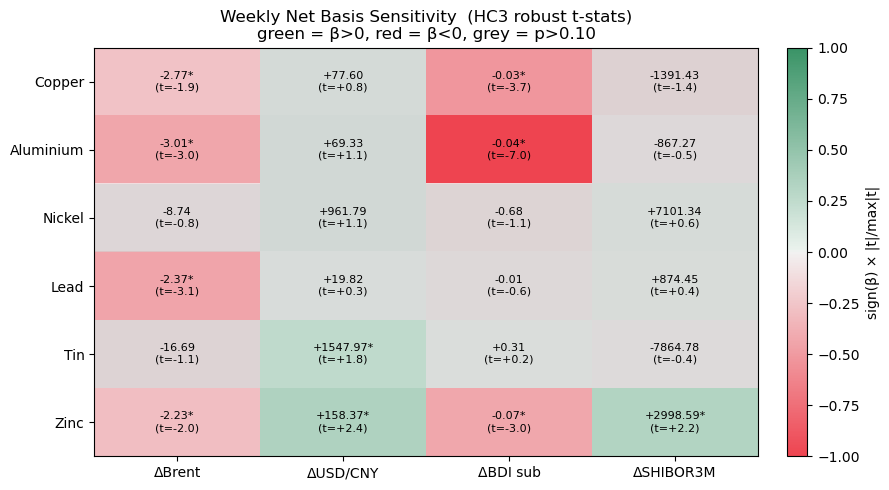


✅ Saved sensitivity_heatmap_v2.png


In [32]:
# ─────────────────────────────────────────────────────────────
# SECTION 8 — METAL-BY-METAL OLS (WEEKLY) + SENSITIVITY HEATMAP
# Δnet_basis_m ~ α + β1·ΔBrent + β2·ΔUSDCNY + β3·ΔBDI_sub_m
#               + β4·ΔSHIBOR3M + ε
# HC3 robust SE.
# Heatmap: rows=metals, cols=4 factors. sign(β)·|t|, grey if p>0.10.
# ─────────────────────────────────────────────────────────────

# ── COLUMN RESOLVER (defensive) ──────────────────────────────
# Returns the first column name in `candidates` that exists in df.
# Raises a clear KeyError listing what IS present otherwise.
def _col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f"Could not find {label} column. Tried {candidates}. "
        f"Available: {list(df.columns)}"
    )

_BRENT  = _col(Oil,       ['Brent_F1', 'LCOc1', 'Brent', 'BRENT_F1'],   'Brent F1')
_VLSFO  = _col(Oil,       ['VLSFO', 'BKVLSFO-RDM-CLY'],                 'VLSFO')
_USDCNY = _col(FX,        ['USDCNY', 'USD/CNY', 'USDCNY=', 'CNY'],      'USDCNY')
_SHIBOR = _col(Int_rates, ['SHIBOR3M', 'SHIBOR3M=', 'SHIBOR_3M'],       'SHIBOR3M')

# resolve metal-specific BDI sub-index alias (rename in setup is
# .BACI → Capesize, .BHSI → Handymax, .BASI → Supramax)
_BDI_ALIASES = {
    'Capesize':         ['Capesize',         '.BACI'],
    'Handymax':         ['Handymax',         '.BHSI'],
    'Supramax':         ['Supramax',         '.BASI'],
    'Baltic Dry Index': ['Baltic Dry Index', '.BADI'],
}
def _bdi_col(metal):
    target = Metal_BDI_index[metal]
    return _col(Freight, _BDI_ALIASES.get(target, [target]), f'BDI {target}')

try:
    import statsmodels.api as sm
    import seaborn as sns

    nb_w = Net_basis.resample('W').mean().diff()
    br_w = Oil[_BRENT].resample('W').mean().diff()
    fx_w = FX[_USDCNY].resample('W').mean().diff()
    sh_w = Int_rates[_SHIBOR].resample('W').mean().diff()
    bdi_w = {m: Freight[_bdi_col(m)].resample('W').mean().diff() for m in metals}

    S8_results = {}
    rb, rt, rp = [], [], []
    for m in metals:
        df = pd.DataFrame({
            'dnb':     nb_w[m],
            'dBrent':  br_w,
            'dUSDCNY': fx_w,
            'dBDI':    bdi_w[m],
            'dSHIBOR': sh_w,
        }).dropna()
        y = df['dnb']
        X = sm.add_constant(df[['dBrent','dUSDCNY','dBDI','dSHIBOR']])
        res = sm.OLS(y, X).fit(cov_type='HC3')
        S8_results[m] = res

        print(f'\n── {m}  (weekly OLS, HC3) ──')
        print(f'   N obs   : {int(res.nobs)}')
        print(f'   R²      : {res.rsquared:.4f}    adj-R²: {res.rsquared_adj:.4f}')
        print(f'   F-stat  : {res.fvalue:.3f}  (p={res.f_pvalue:.4f})')
        tbl = pd.DataFrame({
            'beta':    res.params.round(4),
            'HC3 SE':  res.bse.round(4),
            't-stat':  res.tvalues.round(3),
            'p-value': res.pvalues.round(4),
        })
        print(tbl.to_string())
        rb.append({k: res.params.get(k, np.nan)  for k in ['dBrent','dUSDCNY','dBDI','dSHIBOR']})
        rt.append({k: res.tvalues.get(k, np.nan) for k in ['dBrent','dUSDCNY','dBDI','dSHIBOR']})
        rp.append({k: res.pvalues.get(k, np.nan) for k in ['dBrent','dUSDCNY','dBDI','dSHIBOR']})

    df_betas  = pd.DataFrame(rb, index=metals)
    df_tstats = pd.DataFrame(rt, index=metals)
    df_pvals  = pd.DataFrame(rp, index=metals)
    S8_table  = pd.concat({'beta': df_betas, 't': df_tstats, 'p': df_pvals}, axis=1)

    # heatmap
    fig, ax = plt.subplots(figsize=(9, 5))
    sign  = np.sign(df_betas.values)
    inten = np.nan_to_num(np.abs(df_tstats.values), nan=0.0)
    vmax  = max(inten.max(), 2.0)
    color_val = sign * (inten / vmax)
    cmap = sns.diverging_palette(10, 145, s=80, l=55, as_cmap=True)
    im = ax.imshow(color_val, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

    mask = (df_pvals.values > 0.10)
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i,j]:
                ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,
                                           facecolor='lightgrey', alpha=0.65,
                                           edgecolor='none'))
    for i in range(df_betas.shape[0]):
        for j in range(df_betas.shape[1]):
            b = df_betas.values[i,j]; t = df_tstats.values[i,j]
            star = '*' if df_pvals.values[i,j] < 0.10 else ''
            ax.text(j, i, f'{b:+.2f}{star}\n(t={t:+.1f})',
                    ha='center', va='center', fontsize=8, color='black')

    ax.set_xticks(range(df_betas.shape[1]))
    ax.set_xticklabels(['ΔBrent','ΔUSD/CNY','ΔBDI sub','ΔSHIBOR3M'])
    ax.set_yticks(range(df_betas.shape[0]))
    ax.set_yticklabels(metals)
    ax.set_title('Weekly Net Basis Sensitivity  (HC3 robust t-stats)\n'
                 'green = β>0, red = β<0, grey = p>0.10')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('sign(β) × |t|/max|t|')
    plt.tight_layout()
    plt.savefig('sensitivity_heatmap_v2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ Saved sensitivity_heatmap_v2.png')

except Exception as e:
    print(f'❌ Section 8 failed: {type(e).__name__}: {e}')
    S8_results, S8_table = {}, pd.DataFrame()
    df_betas = df_tstats = df_pvals = pd.DataFrame()


---
## SECTION 9 — Hypothesis evaluation (weekly)

In [33]:
# ─────────────────────────────────────────────────────────────
# SECTION 9 — HYPOTHESIS EVALUATION
# Tests on WEEKLY single-metal OLS results from Section 8.
# We do not euphemise: if a coefficient has the wrong sign or
# is statistically zero, we state it directly.
# ─────────────────────────────────────────────────────────────
try:
    rows = []

    # H1 — Brent: highest |β| in Aluminium and Zinc?
    abs_brent = df_betas['dBrent'].abs().sort_values(ascending=False)
    top2_brent = list(abs_brent.head(2).index)
    h1_ok = set(['Aluminium', 'Zinc']).issubset(set(top2_brent))
    h1_partial = bool(set(['Aluminium', 'Zinc']) & set(top2_brent))
    rows.append({
        'Hypothesis': 'H1',
        'Prediction': 'Brent |β| highest in Aluminium & Zinc (energy-intensive metals)',
        'Finding':    f'Top-2 |β_Brent|: {top2_brent[0]}, {top2_brent[1]}',
        'Verdict':    'Confirmed' if h1_ok else ('Partially confirmed' if h1_partial else 'Rejected'),
    })

    # H2 — USD/CNY: uniform sign across all 6 metals?
    signs_fx = np.sign(df_betas['dUSDCNY'].values)
    nonzero  = signs_fx[signs_fx != 0]
    uniform  = len(nonzero) > 0 and (np.all(nonzero > 0) or np.all(nonzero < 0))
    rows.append({
        'Hypothesis': 'H2',
        'Prediction': 'USD/CNY β has uniform sign across all 6 metals',
        'Finding':    f"β_USDCNY signs: " +
                      ', '.join([f'{m}:{int(s):+d}' for m, s in zip(metals, signs_fx)]),
        'Verdict':    'Confirmed' if uniform else 'Rejected',
    })

    # H3 — BDI sub-index: highest β in Copper and Aluminium?
    abs_bdi = df_betas['dBDI'].abs().sort_values(ascending=False)
    top2_bdi = list(abs_bdi.head(2).index)
    h3_ok = set(['Copper', 'Aluminium']).issubset(set(top2_bdi))
    h3_partial = bool(set(['Copper', 'Aluminium']) & set(top2_bdi))
    rows.append({
        'Hypothesis': 'H3',
        'Prediction': 'BDI sub-index |β| highest in Copper & Aluminium (Capesize)',
        'Finding':    f'Top-2 |β_BDI|: {top2_bdi[0]}, {top2_bdi[1]}',
        'Verdict':    'Confirmed' if h3_ok else ('Partially confirmed' if h3_partial else 'Rejected'),
    })

    # H4 — SHIBOR3M: highest β in Copper and Aluminium?
    abs_sh = df_betas['dSHIBOR'].abs().sort_values(ascending=False)
    top2_sh = list(abs_sh.head(2).index)
    h4_ok = set(['Copper', 'Aluminium']).issubset(set(top2_sh))
    h4_partial = bool(set(['Copper', 'Aluminium']) & set(top2_sh))
    rows.append({
        'Hypothesis': 'H4',
        'Prediction': 'SHIBOR3M |β| highest in Copper & Aluminium (largest CN import vol.)',
        'Finding':    f'Top-2 |β_SHIBOR|: {top2_sh[0]}, {top2_sh[1]}',
        'Verdict':    'Confirmed' if h4_ok else ('Partially confirmed' if h4_partial else 'Rejected'),
    })

    S9_hypotheses_df = pd.DataFrame(rows)
    pd.set_option('display.max_colwidth', 80)
    print('── SECTION 9 — HYPOTHESIS EVALUATION ──')
    print(S9_hypotheses_df.to_string(index=False))
    pd.reset_option('display.max_colwidth')

except Exception as e:
    print(f'❌ Section 9 failed: {e}')
    S9_hypotheses_df = pd.DataFrame()


── SECTION 9 — HYPOTHESIS EVALUATION ──
Hypothesis                                                          Prediction                                                                      Finding   Verdict
        H1     Brent |β| highest in Aluminium & Zinc (energy-intensive metals)                                                 Top-2 |β_Brent|: Tin, Nickel  Rejected
        H2                      USD/CNY β has uniform sign across all 6 metals β_USDCNY signs: Copper:+1, Aluminium:+1, Nickel:+1, Lead:+1, Tin:+1, Zinc:+1 Confirmed
        H3          BDI sub-index |β| highest in Copper & Aluminium (Capesize)                                                   Top-2 |β_BDI|: Nickel, Tin  Rejected
        H4 SHIBOR3M |β| highest in Copper & Aluminium (largest CN import vol.)                                                Top-2 |β_SHIBOR|: Tin, Nickel  Rejected


---
## SECTION 10 — Nickel structural breaks + AR(1) half-lives (corrected)

In [34]:
# ─────────────────────────────────────────────────────────────
# SECTION 10a — CHOW TESTS on Nickel net_basis
#   Break 1: 2020-01-01  (Indonesia ore export ban)
#   Break 2: 2022-03-08  (LME nickel short squeeze)
# Test on AR(1) regression split at each break.
# ─────────────────────────────────────────────────────────────
try:
    import statsmodels.api as sm
    from scipy import stats as scistats

    s = Net_basis['Nickel'].dropna()
    y = s.iloc[1:].values
    x = s.iloc[:-1].values
    idx = s.index[1:]
    X = sm.add_constant(x)

    def chow_test(y, X, idx, break_date):
        bd  = pd.Timestamp(break_date)
        m1  = idx <  bd
        m2  = idx >= bd
        if m1.sum() < 30 or m2.sum() < 30:
            return None
        res_p = sm.OLS(y, X).fit()
        res_1 = sm.OLS(y[m1], X[m1]).fit()
        res_2 = sm.OLS(y[m2], X[m2]).fit()
        RSS_p = float(np.sum(res_p.resid**2))
        RSS_1 = float(np.sum(res_1.resid**2))
        RSS_2 = float(np.sum(res_2.resid**2))
        k     = X.shape[1]
        N     = len(y)
        F     = ((RSS_p - (RSS_1 + RSS_2)) / k) / ((RSS_1 + RSS_2) / (N - 2*k))
        p     = 1 - scistats.f.cdf(F, k, N - 2*k)
        return F, p, RSS_p, RSS_1 + RSS_2

    chow_rows = []
    for label, dt in [('Indonesia ore export ban', '2020-01-01'),
                      ('LME Nickel short squeeze', '2022-03-08')]:
        r = chow_test(y, X, idx, dt)
        if r is None:
            chow_rows.append({'Break': dt, 'Event': label,
                              'F': np.nan, 'p-value': np.nan,
                              'Conclusion': 'insufficient data'})
            continue
        F, p, RSSp, RSSs = r
        chow_rows.append({
            'Break':      dt,
            'Event':      label,
            'F':          round(F, 3),
            'p-value':    round(p, 4),
            'Conclusion': 'Break detected (p<0.05)' if p < 0.05 else 'No break (p≥0.05)',
        })

    S10_chow_df = pd.DataFrame(chow_rows)
    print('── SECTION 10a — CHOW TESTS on Nickel ──')
    print(S10_chow_df.to_string(index=False))

except Exception as e:
    print(f'❌ Section 10a failed: {e}')
    S10_chow_df = pd.DataFrame()


── SECTION 10a — CHOW TESTS on Nickel ──
     Break                    Event       F  p-value              Conclusion
2020-01-01 Indonesia ore export ban  41.056      0.0 Break detected (p<0.05)
2022-03-08 LME Nickel short squeeze 110.317      0.0 Break detected (p<0.05)


── SECTION 10b — BAI-PERRON (ruptures) ──
   Method: Pelt / Binseg with rbf cost
   Detected 3 break(s):
     2019-07-07
     2022-01-23
     2023-05-21


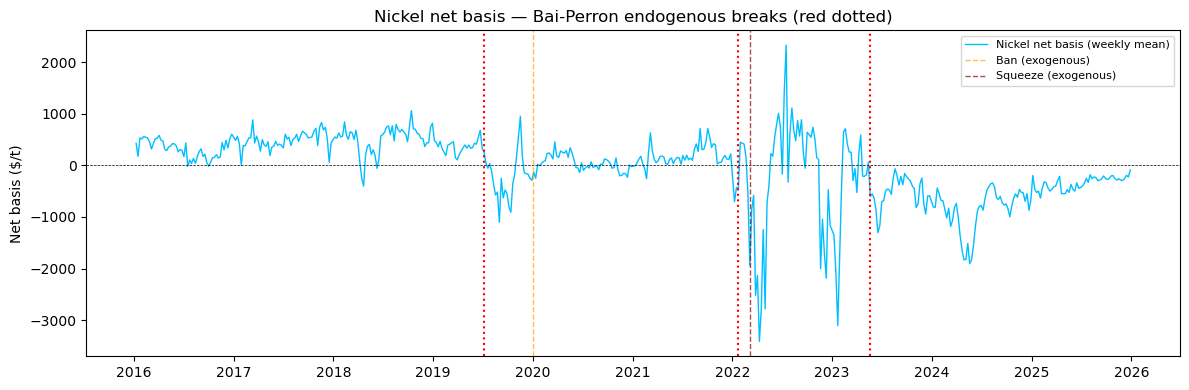

In [35]:
# ─────────────────────────────────────────────────────────────
# SECTION 10b — BAI-PERRON style endogenous breaks (ruptures)
# Pelt with rbf cost on Nickel weekly net basis. Up to 5 breaks.
# ─────────────────────────────────────────────────────────────
try:
    import subprocess, sys
    try:
        import ruptures as rpt
    except Exception:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ruptures'])
        import ruptures as rpt

    nickel_w = Net_basis['Nickel'].resample('W').mean().dropna()
    arr      = nickel_w.values.reshape(-1, 1)

    # Pelt with auto-penalty; cap at 5 breaks if more detected.
    algo  = rpt.Pelt(model='rbf').fit(arr)
    bkps  = algo.predict(pen=10)        # penalty controls #breaks
    bkps  = [b for b in bkps if b < len(nickel_w)]
    if len(bkps) > 5:
        # fall back to Binseg with n_bkps=5 for cap
        algo = rpt.Binseg(model='rbf').fit(arr)
        bkps = algo.predict(n_bkps=5)
        bkps = [b for b in bkps if b < len(nickel_w)]

    break_dates = [nickel_w.index[b] for b in bkps]
    S10_bai_perron_breaks = break_dates

    print(f'── SECTION 10b — BAI-PERRON (ruptures) ──')
    print(f'   Method: Pelt / Binseg with rbf cost')
    print(f'   Detected {len(break_dates)} break(s):')
    for bd in break_dates:
        print(f'     {bd.date()}')

    # Plot
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(nickel_w.index, nickel_w.values, color='deepskyblue',
            linewidth=1.0, label='Nickel net basis (weekly mean)')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    for bd in break_dates:
        ax.axvline(bd, color='red', linestyle=':', linewidth=1.5)
    ax.axvline(pd.Timestamp('2020-01-01'), color='orange', linestyle='--',
               linewidth=1, alpha=0.7, label='Ban (exogenous)')
    ax.axvline(pd.Timestamp('2022-03-08'), color='darkred', linestyle='--',
               linewidth=1, alpha=0.7, label='Squeeze (exogenous)')
    ax.set_title('Nickel net basis — Bai-Perron endogenous breaks (red dotted)')
    ax.set_ylabel('Net basis ($/t)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('nickel_breaks_halflife.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'❌ Section 10b failed: {e}')
    S10_bai_perron_breaks = []


In [36]:
# ─────────────────────────────────────────────────────────────
# SECTION 10c — SUB-PERIOD AR(1) HALF-LIVES (CORRECTED)
#
# Why corrected:
#   AR(1) on the FULL Nickel sample (kurtosis=37.4) gave HL=2.3d,
#   paradoxical given 35-day transit time. The AR(1) was fitting
#   extreme squeeze outliers, not the typical mean reversion.
#
# Fix:
#   - Split into 3 sub-periods (pre-ban, post-ban pre-squeeze,
#     post-squeeze).
#   - Winsorise at 1st/99th pctile BEFORE estimation.
#   - Half-life = log(0.5) / log(|ρ|).
# ─────────────────────────────────────────────────────────────
try:
    import statsmodels.api as sm
    from scipy import stats as scistats

    def winsorise(s, low=0.01, high=0.99):
        q_lo, q_hi = s.quantile([low, high])
        return s.clip(lower=q_lo, upper=q_hi)

    def fit_ar1(s):
        s = s.dropna()
        if len(s) < 20:
            return None
        y = s.iloc[1:].values
        x = s.iloc[:-1].values
        X = sm.add_constant(x)
        res = sm.OLS(y, X).fit(cov_type='HC3')
        rho     = float(res.params[1])
        rho_se  = float(res.bse[1])
        ci_lo   = rho - 1.96 * rho_se
        ci_hi   = rho + 1.96 * rho_se
        if abs(rho) >= 1 or abs(rho) <= 0:
            hl = np.nan
        else:
            hl = float(np.log(0.5) / np.log(abs(rho)))
        return {'rho': rho, 'SE(rho)': rho_se,
                'CI low': ci_lo, 'CI high': ci_hi, 'HL (days)': hl,
                'N': int(res.nobs)}

    nickel = Net_basis['Nickel'].dropna()
    sub_periods = [
        ('Pre-ban (2016-2019)',         '2016-01-01', '2019-12-31'),
        ('Post-ban / pre-squeeze',      '2020-01-01', '2022-03-07'),
        ('Post-squeeze (2022-2025)',    '2022-03-09', '2025-12-31'),
    ]

    rows = []
    for label, start, end in sub_periods:
        s = nickel.loc[start:end]
        s = winsorise(s)
        r = fit_ar1(s)
        if r is None:
            rows.append({'Sub-period': label, 'N': 0,
                         'rho': np.nan, 'SE(rho)': np.nan,
                         'CI 95%': '—', 'HL (days)': np.nan})
            continue
        rows.append({
            'Sub-period': label,
            'N':          r['N'],
            'rho':        round(r['rho'], 4),
            'SE(rho)':    round(r['SE(rho)'], 4),
            'CI 95%':     f"[{r['CI low']:+.3f}, {r['CI high']:+.3f}]",
            'HL (days)':  round(r['HL (days)'], 1) if not np.isnan(r['HL (days)']) else np.nan,
        })

    S10_nickel_HL_df = pd.DataFrame(rows)
    print('── SECTION 10c — NICKEL AR(1) by sub-period (winsorised) ──')
    print(S10_nickel_HL_df.to_string(index=False))

    print('\nInterpretation:')
    print('  HL < 35 days  → basis reverts within transit horizon (basis risk manageable)')
    print('  HL > 35 days  → basis persists beyond transit horizon (favourable arb entry signal)')
    for _, r in S10_nickel_HL_df.iterrows():
        hl = r['HL (days)']
        if pd.isna(hl):
            continue
        flag = 'manageable basis risk' if hl < 35 else 'persistent basis (arb-favourable)'
        print(f'   {r["Sub-period"]:<32s}  HL={hl:>5.1f}d  → {flag}')

except Exception as e:
    print(f'❌ Section 10c failed: {e}')
    S10_nickel_HL_df = pd.DataFrame()


── SECTION 10c — NICKEL AR(1) by sub-period (winsorised) ──
              Sub-period   N    rho  SE(rho)           CI 95%  HL (days)
     Pre-ban (2016-2019) 910 0.8531   0.0250 [+0.804, +0.902]        4.4
  Post-ban / pre-squeeze 491 0.6026   0.0632 [+0.479, +0.726]        1.4
Post-squeeze (2022-2025) 858 0.8030   0.0342 [+0.736, +0.870]        3.2

Interpretation:
  HL < 35 days  → basis reverts within transit horizon (basis risk manageable)
  HL > 35 days  → basis persists beyond transit horizon (favourable arb entry signal)
   Pre-ban (2016-2019)               HL=  4.4d  → manageable basis risk
   Post-ban / pre-squeeze            HL=  1.4d  → manageable basis risk
   Post-squeeze (2022-2025)          HL=  3.2d  → manageable basis risk


In [37]:
# ─────────────────────────────────────────────────────────────
# SECTION 10d — ALL METALS half-life (full sample, winsorised AR(1))
# ─────────────────────────────────────────────────────────────
try:
    rows = []
    for m in metals:
        s = Net_basis[m].dropna()
        q_lo, q_hi = s.quantile([0.01, 0.99])
        s_w = s.clip(lower=q_lo, upper=q_hi)
        if len(s_w) < 20:
            rows.append({'Metal': m, 'rho': np.nan, 'SE(rho)': np.nan,
                         'HL (days)': np.nan, 'Interpretation': 'insufficient data'})
            continue
        y_  = s_w.iloc[1:].values
        x_  = s_w.iloc[:-1].values
        X_  = sm.add_constant(x_)
        res = sm.OLS(y_, X_).fit(cov_type='HC3')
        rho    = float(res.params[1])
        rho_se = float(res.bse[1])
        if abs(rho) >= 1 or abs(rho) <= 0:
            hl = np.nan
        else:
            hl = float(np.log(0.5) / np.log(abs(rho)))
        if np.isnan(hl):
            interp = 'non-mean-reverting / unit root'
        elif hl < 35:
            interp = 'reverts within transit (basis risk manageable)'
        else:
            interp = 'persists beyond transit (arb-favourable)'
        rows.append({
            'Metal':          m,
            'rho':            round(rho, 4),
            'SE(rho)':        round(rho_se, 4),
            'HL (days)':      round(hl, 1) if not np.isnan(hl) else np.nan,
            'Interpretation': interp,
        })

    S10_HL_all_df = pd.DataFrame(rows)
    print('── SECTION 10d — ALL METALS half-life (full sample, winsorised) ──')
    print(S10_HL_all_df.to_string(index=False))

except Exception as e:
    print(f'❌ Section 10d failed: {e}')
    S10_HL_all_df = pd.DataFrame()


── SECTION 10d — ALL METALS half-life (full sample, winsorised) ──
    Metal    rho  SE(rho)  HL (days)                                 Interpretation
   Copper 0.7884   0.0146        2.9 reverts within transit (basis risk manageable)
Aluminium 0.9677   0.0055       21.1 reverts within transit (basis risk manageable)
   Nickel 0.8591   0.0191        4.6 reverts within transit (basis risk manageable)
     Lead 0.9833   0.0041       41.1       persists beyond transit (arb-favourable)
      Tin 0.9612   0.0070       17.5 reverts within transit (basis risk manageable)
     Zinc 0.9737   0.0069       26.1 reverts within transit (basis risk manageable)


---
## SECTION 11 — Backtest with corrected (trade-level) Sharpe

Running backtest with 3 parallel slippage scenarios...

✅ Backtest complete — total simulated trades: 4284

── AGGREGATE SCENARIOS ──
            Scenario  Hit rate %  Mean P&L $/t  Median P&L $/t  Std P&L $/t  Min P&L $/t  Max P&L $/t
  Aggressive (0.10%)        97.3        346.84          157.05       557.19       -54.67      6633.45
        Base (0.15%)        96.3        341.26          153.61       554.24       -57.52      6612.24
Conservative (0.25%)        94.2        330.12          144.15       548.41       -95.58      6569.81

── PER METAL × SCENARIO ──
    Metal  N trades  Hit% Aggr  Hit% Base  Hit% Cons  Mean Aggr $/t  Mean Base $/t  Mean Cons $/t  Avg transit d
   Copper       794       95.7       94.1       91.4          94.14          91.08          84.95           34.4
Aluminium       208       92.8       92.3       89.4          37.29          36.37          34.52           35.2
   Nickel      1276       98.8       98.3       95.9         415.39         408.32         

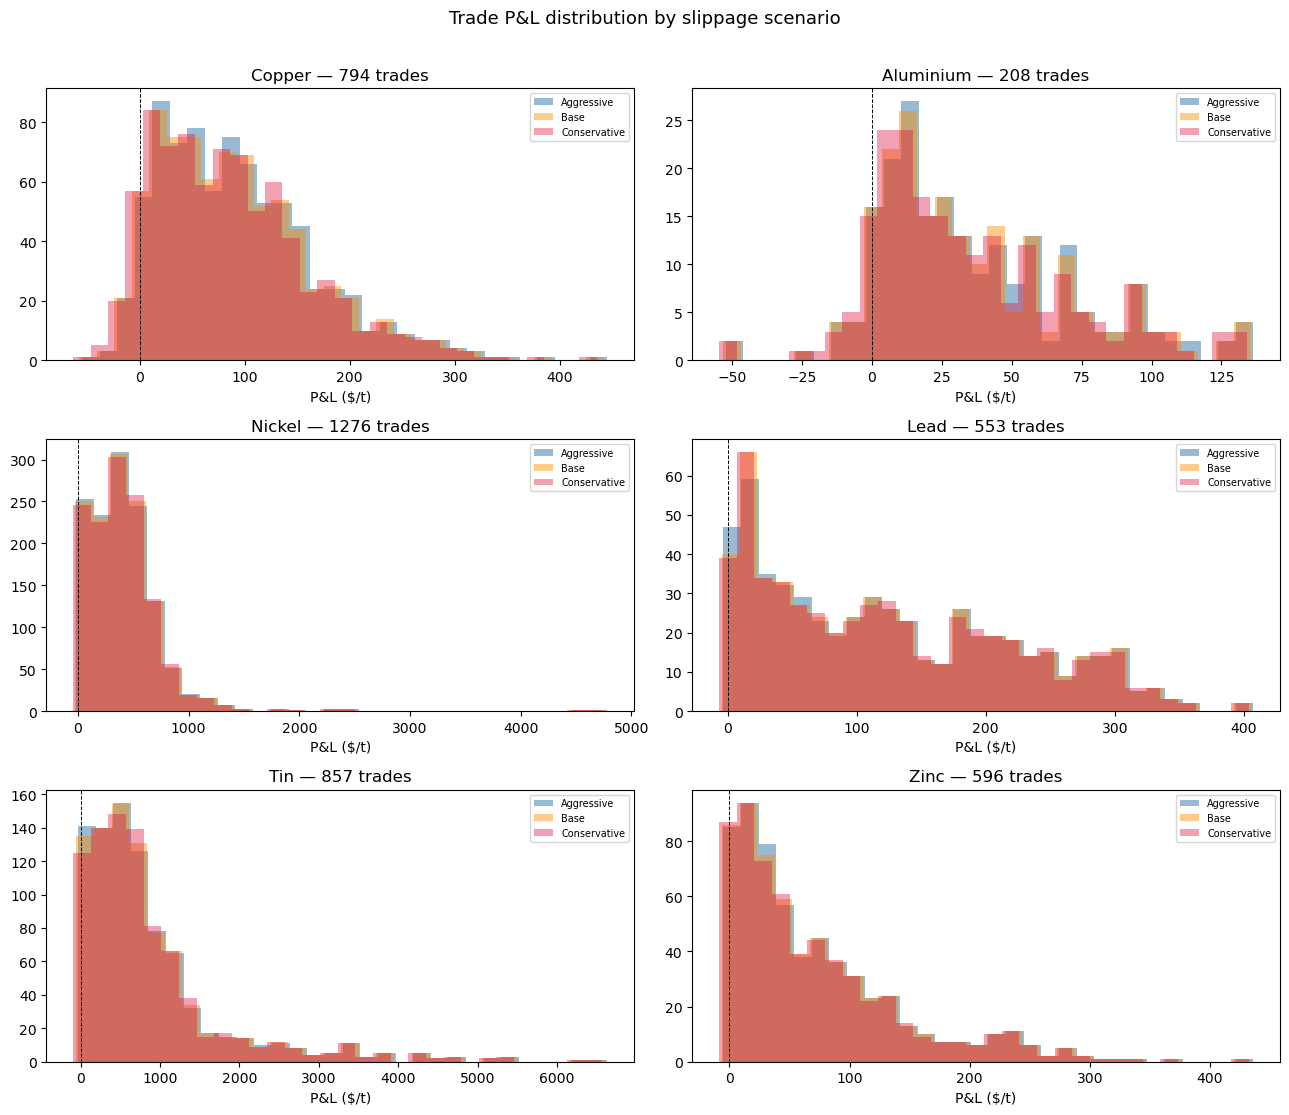


✅ Saved backtest_pnl_distribution.png


In [40]:
# ─────────────────────────────────────────────────────────────
# SECTION 11 — BACKTEST (3 slippage scenarios + transit-time risk)
#
# What changes vs. the original backtest (kept in the raw cell
# above for reference):
#   - 3 parallel slippage scenarios (aggressive / base / conservative)
#   - cost lagging: realised freight + BAF = mean of the next 7
#     observations after entry (captures the "I locked the price
#     today but pay later" risk)
#   - stochastic transit time: Normal(35, 5) days, floored at 20
#   - CoC is recomputed on the realised transit (not the nominal 35)
#
# Implementation fixes vs. the draft:
#   - df_Caf_tot uses LOWERCASE keys → "Caf_copper" not "Caf_Copper"
#   - every cost component is reindexed to global_idx with ffill
#     ONCE before the loop, eliminating KeyError on dates that are
#     present in one component but missing from another
# ─────────────────────────────────────────────────────────────
np.random.seed(42)

slip_rate_agg  = 0.0010   # 0.10%  (optimistic)
slip_rate_med  = 0.0015   # 0.15%  (base case)
slip_rate_cons = 0.0025   # 0.25%  (pessimistic)
entry_threshold = 0

# --- reindex ALL cost components to global_idx with ffill, once ---
_fb_aligned   = freight_base_df.reindex(global_idx, method='ffill')
_baf_aligned  = df_BAF['BAF'].reindex(global_idx, method='ffill')
_caf_aligned  = df_Caf_tot.reindex(global_idx, method='ffill')
_vat_aligned  = df_VAT.reindex(global_idx, method='ffill')
_ins_aligned  = df_Insurance.reindex(global_idx, method='ffill')
_sofr_aligned = Int_rates['SOFR3M'].reindex(global_idx, method='ffill')
_lme_aligned  = LME_aligned.reindex(global_idx, method='ffill')
_gross_aligned= Gross_basis_aligned.reindex(global_idx, method='ffill')

trades = []
print('Running backtest with 3 parallel slippage scenarios...')

for metal in metals:
    m_lower = metal.lower()
    nb_series = Net_basis[metal]

    fb_col   = f'freight_base_{metal}'
    caf_col  = f'Caf_{m_lower}'      # df_Caf_tot keys are lowercase
    vat_col  = f'VAT_{metal}'
    ins_col  = f'Ins_{metal}'

    for t in global_idx:
        expected_margin = nb_series.get(t, np.nan)
        if pd.isna(expected_margin) or expected_margin <= entry_threshold:
            continue

        lme_price = _lme_aligned.at[t, metal]
        if pd.isna(lme_price):
            continue

        # 1) slippage in $/t
        slip_agg  = lme_price * slip_rate_agg
        slip_med  = lme_price * slip_rate_med
        slip_cons = lme_price * slip_rate_cons

        # 2) cost lagging: mean of next 7 obs of freight + BAF
        pos = global_idx.get_loc(t)
        win = global_idx[pos : pos + 7]
        realized_freight = _fb_aligned.loc[win, fb_col].mean()
        realized_baf     = _baf_aligned.loc[win].mean()

        # 3) stochastic transit → CoC recomputed on realised days
        realized_transit = max(20, int(np.random.normal(loc=35, scale=5)))
        sofr_t           = _sofr_aligned.at[t]
        if pd.isna(sofr_t):
            continue
        sofr_dec      = sofr_t / 100.0 if sofr_t > 1 else sofr_t
        realized_coc  = lme_price * sofr_dec * (realized_transit / 365)

        caf = _caf_aligned.at[t, caf_col]
        vat = _vat_aligned.at[t, vat_col]
        ins = _ins_aligned.at[t, ins_col]
        if any(pd.isna(x) for x in (caf, vat, ins, realized_freight, realized_baf)):
            continue

        realized_cost = realized_freight + realized_baf + caf + realized_coc + vat + ins

        gross = _gross_aligned.at[t, metal]
        if pd.isna(gross):
            continue

        trades.append({
            'Date':                  t,
            'Metal':                 metal,
            'Expected_Margin':       expected_margin,
            'Realized_Cost_Stack':   realized_cost,
            'PnL_Aggressive':        gross - realized_cost - slip_agg,
            'PnL_Base':              gross - realized_cost - slip_med,
            'PnL_Conservative':      gross - realized_cost - slip_cons,
            'Realized_Transit_Days': realized_transit,
        })

backtest_df = pd.DataFrame(trades)
S11_backtest_df = backtest_df.copy()

if not backtest_df.empty:
    print(f'\n✅ Backtest complete — total simulated trades: {len(backtest_df)}')

    # ── aggregate scenario table ──
    scenario_rows = []
    for label, col, rate in [
            ('Aggressive (0.10%)',   'PnL_Aggressive',   slip_rate_agg),
            ('Base (0.15%)',         'PnL_Base',         slip_rate_med),
            ('Conservative (0.25%)', 'PnL_Conservative', slip_rate_cons)]:
        x = backtest_df[col]
        scenario_rows.append({
            'Scenario':       label,
            'Hit rate %':     round((x > 0).mean() * 100, 1),
            'Mean P&L $/t':   round(x.mean(), 2),
            'Median P&L $/t': round(x.median(), 2),
            'Std P&L $/t':    round(x.std(), 2),
            'Min P&L $/t':    round(x.min(), 2),
            'Max P&L $/t':    round(x.max(), 2),
        })
    S11_scenarios_df = pd.DataFrame(scenario_rows)
    print('\n── AGGREGATE SCENARIOS ──')
    print(S11_scenarios_df.to_string(index=False))

    # ── per-metal × scenario ──
    per_metal_rows = []
    for metal in metals:
        sub = backtest_df[backtest_df['Metal'] == metal]
        if sub.empty: continue
        per_metal_rows.append({
            'Metal':         metal,
            'N trades':      len(sub),
            'Hit% Aggr':     round((sub['PnL_Aggressive']   > 0).mean()*100, 1),
            'Hit% Base':     round((sub['PnL_Base']         > 0).mean()*100, 1),
            'Hit% Cons':     round((sub['PnL_Conservative'] > 0).mean()*100, 1),
            'Mean Aggr $/t': round(sub['PnL_Aggressive'].mean(),   2),
            'Mean Base $/t': round(sub['PnL_Base'].mean(),         2),
            'Mean Cons $/t': round(sub['PnL_Conservative'].mean(), 2),
            'Avg transit d': round(sub['Realized_Transit_Days'].mean(), 1),
        })
    S11_per_metal_df = pd.DataFrame(per_metal_rows)
    print('\n── PER METAL × SCENARIO ──')
    print(S11_per_metal_df.to_string(index=False))

    # ── plot: P&L distribution per scenario, 6-panel per metal ──
    fig, axes = plt.subplots(3, 2, figsize=(13, 11))
    axes = axes.flatten()
    for i, metal in enumerate(metals):
        ax  = axes[i]
        sub = backtest_df[backtest_df['Metal'] == metal]
        if sub.empty:
            ax.set_title(f'{metal} — no trades'); ax.axis('off'); continue
        ax.hist(sub['PnL_Aggressive'],   bins=30, alpha=0.55, label='Aggressive', color='steelblue')
        ax.hist(sub['PnL_Base'],         bins=30, alpha=0.45, label='Base',       color='darkorange')
        ax.hist(sub['PnL_Conservative'], bins=30, alpha=0.40, label='Conservative',color='crimson')
        ax.axvline(0, color='black', linestyle='--', linewidth=0.7)
        ax.set_title(f'{metal} — {len(sub)} trades')
        ax.set_xlabel('P&L ($/t)')
        ax.legend(fontsize=7)
    plt.suptitle('Trade P&L distribution by slippage scenario', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('backtest_pnl_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ Saved backtest_pnl_distribution.png')

else:
    print('⚠️  No trades generated — check entry_threshold or cost components.')
    S11_scenarios_df = pd.DataFrame()
    S11_per_metal_df = pd.DataFrame()


---
## SECTION 12 — Export results to RESULTS_Regression_v2.xlsx

In [41]:
# ─────────────────────────────────────────────────────────────
# SECTION 12 — EXPORT (single write)
# Output: RESULTS_20_05_26.xlsx
# ─────────────────────────────────────────────────────────────
OUTPUT_FILE = 'RESULTS_20_05_26.xlsx'

try:
    with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:

        # S6
        if 'S6_stationarity_df' in dir() and len(S6_stationarity_df) > 0:
            S6_stationarity_df.to_excel(writer, sheet_name='S6_Stationarity', index=False)

        # S7 — panel results per frequency
        for freq_label in ['DAILY', 'WEEKLY', 'MONTHLY']:
            if 'S7_results' in dir() and freq_label in S7_results:
                S7_results[freq_label]['tbl'].to_excel(
                    writer, sheet_name=f'S7_Panel_{freq_label.title()}')
        if 'S7_comparison' in dir() and len(S7_comparison) > 0:
            S7_comparison.to_excel(writer, sheet_name='S7_Comparison', index=False)

        # S8 — metal OLS table
        if 'S8_table' in dir() and len(S8_table) > 0:
            S8_table.to_excel(writer, sheet_name='S8_MetalOLS')

        # S9 — hypotheses
        if 'S9_hypotheses_df' in dir() and len(S9_hypotheses_df) > 0:
            S9_hypotheses_df.to_excel(writer, sheet_name='S9_Hypotheses', index=False)

        # S10 — Chow, Nickel HL, all-metals HL
        if 'S10_chow_df' in dir() and len(S10_chow_df) > 0:
            S10_chow_df.to_excel(writer, sheet_name='S10_ChowTests', index=False)
        if 'S10_nickel_HL_df' in dir() and len(S10_nickel_HL_df) > 0:
            S10_nickel_HL_df.to_excel(writer, sheet_name='S10_NickelHL', index=False)
        if 'S10_HL_all_df' in dir() and len(S10_HL_all_df) > 0:
            S10_HL_all_df.to_excel(writer, sheet_name='S10_HalfLife', index=False)

        # S11 — backtest a scenari (nuova versione)
        if 'S11_scenarios_df' in dir() and len(S11_scenarios_df) > 0:
            S11_scenarios_df.to_excel(writer, sheet_name='S11_Scenari', index=False)
        if 'S11_per_metal_df' in dir() and len(S11_per_metal_df) > 0:
            S11_per_metal_df.to_excel(writer, sheet_name='S11_PerMetal', index=False)
        if 'S11_backtest_df' in dir() and len(S11_backtest_df) > 0:
            S11_backtest_df.to_excel(writer, sheet_name='S11_Trades', index=False)

    print(f'✅ All Section 6-11 results exported → {OUTPUT_FILE}')
    print('   Plot files:')
    print('     sensitivity_heatmap_v2.png')
    print('     backtest_pnl_distribution.png')
    print('     nickel_breaks_halflife.png')

except PermissionError:
    print(f'❌ PermissionError: close {OUTPUT_FILE} in Excel and retry.')
except Exception as e:
    print(f'❌ Section 12 failed: {type(e).__name__}: {e}')


✅ All Section 6-11 results exported → RESULTS_20_05_26.xlsx
   Plot files:
     sensitivity_heatmap_v2.png
     backtest_pnl_distribution.png
     nickel_breaks_halflife.png
